In [2]:
import os
import glob
import json

import torch
import pandas as pd

from torch.utils.data import Dataset
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from transformer_lens import HookedTransformer, HookedTransformerConfig

from dictionary_learning import AutoEncoder

from dictionary_learning import utils as dl_utils

from tqdm import tqdm

In [3]:
E = 100
T = 10
SEP = E + T  # 110
Q = E + T + 1  # 111
PAD = E + T + 2  # 112
D_VOCAB = E + T + 3


class EntityBindingDataset(Dataset):
    def __init__(self, dataframe, parse_tokens_if_str=True):
        self.df = dataframe.reset_index(drop=True)
        self.parse_tokens_if_str = parse_tokens_if_str

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = row["tokens"]
        tokens = torch.tensor(seq, dtype=torch.long)
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return tokens, label


dataset = load_dataset("sojup/entity_binding", split="test")
test_df = dataset.to_pandas()
test_dataset = EntityBindingDataset(test_df)

len(test_dataset), test_dataset[0]

(8000,
 (tensor([ 10, 104,   1, 110,  20, 103,  30, 110,  70, 105,  37, 110,  30, 100,
           24, 110, 105,  70, 111]),
  tensor(37)))

In [4]:
REPO_ID = "sebastianhoenig/2L2H_Final"
FILENAME = "D256_L2_H2_attnOnly1_lr5.0e-04_wd0.01.pt"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

d_model = 256
n_ctx = 64
N_LAYERS = 2
HEADS = 2


def build_model(n_layers: int = 2, n_heads: int = 2) -> HookedTransformer:
    d_head = d_model // n_heads
    cfg = HookedTransformerConfig(
        n_layers=n_layers,
        n_heads=n_heads,
        d_model=d_model,
        d_head=d_head,
        n_ctx=n_ctx,
        d_vocab=D_VOCAB,
        d_vocab_out=E,
        attn_only=True,
        normalization_type="LN",
        positional_embedding_type="rotary",
    )
    return HookedTransformer(cfg)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(N_LAYERS, HEADS).to(device)
pretrained_weights = torch.load(weights_path, map_location=device, weights_only=True)
state_dict = pretrained_weights["model"]
model.load_state_dict(state_dict)
model.cfg.use_attn_result = True
model.eval()

print("Model loaded.")

Moving model to device:  cpu
Model loaded.


In [5]:
REPO_ID = "sojup/entity_binding_test"
FILENAME = "id_to_entity.csv"

id_mapping_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)
id_mapping_df = pd.read_csv(id_mapping_path)
id_to_entity = dict(zip(id_mapping_df["id"], id_mapping_df["name"]))

id_to_entity[100] = "loves"
id_to_entity[101] = "works with"
id_to_entity[102] = "interacts with"
id_to_entity[103] = "lives with"
id_to_entity[104] = "has a grudge against"
id_to_entity[105] = "is interested in"
id_to_entity[106] = "plays with"
id_to_entity[107] = "goes to school with"
id_to_entity[108] = "is jealous of"
id_to_entity[109] = "wants"

id_to_entity_rev = {v: k for k, v in id_to_entity.items()}


In [6]:
def load_autoencoder(ckpt_path: str, device=device):
    print("Loading SAE from:", ckpt_path)


    ae, cfg = dl_utils.load_dictionary(ckpt_path, device=device)
    ae.eval()
    return ae, cfg


In [7]:
sae, sae_cfg = load_autoencoder("b0_residpost_sep_d1024_k8_500000", device=device)

Loading SAE from: b0_residpost_sep_d1024_k8_500000


In [8]:
sae

BatchTopKSAE(
  (decoder): Linear(in_features=1024, out_features=256, bias=False)
  (encoder): Linear(in_features=256, out_features=1024, bias=True)
)

In [9]:
def render_tokens(tokens):
    return [id_to_entity[int(tok)] for tok in tokens]


def extract_facts(tokens):
    facts = []
    comma_positions = (tokens == SEP).nonzero(as_tuple=False).flatten().tolist()
    q_pos = (tokens == Q).nonzero(as_tuple=False).flatten().tolist()
    assert len(q_pos) == 1
    q_pos = q_pos[0]

    query_t = int(tokens[q_pos - 2].item())
    query_e1 = int(tokens[q_pos - 1].item())

    for slot_idx, p in enumerate(comma_positions):
        fact = {
            "slot_idx": slot_idx,
            "comma_pos": p,
            "e1": int(tokens[p - 3].item()),
            "t": int(tokens[p - 2].item()),
            "e2": int(tokens[p - 1].item()),
        }
        fact["matches_query"] = fact["e1"] == query_e1 and fact["t"] == query_t
        facts.append(fact)

    query = {"query_e1": query_e1, "query_t": query_t}
    return facts, query


def pretty_print_example(tokens, label):
    facts, query = extract_facts(tokens)

    print("Prompt:")
    print(" ".join(render_tokens(tokens)))
    print()
    print("Facts:")
    for fact in facts:
        mark = " <-- target fact" if fact["matches_query"] else ""
        print(
            f"[{fact['slot_idx']}] "
            f"{id_to_entity[fact['e1']]} | "
            f"{id_to_entity[fact['t']]} | "
            f"{id_to_entity[fact['e2']]} "
            f"(comma pos {fact['comma_pos']}){mark}"
        )
    print()
    print("Query:")
    print(id_to_entity[query["query_t"]], id_to_entity[query["query_e1"]], "?")
    print("Correct label:", id_to_entity[int(label.item())])


In [10]:
example_idx = 0
tokens, label = test_dataset[example_idx]
pretty_print_example(tokens, label)


Prompt:
Jeffery has a grudge against Angel , Linda lives with Lindsay , Jason is interested in Christine , Lindsay loves Susan , is interested in Jason ?

Facts:
[0] Jeffery | has a grudge against | Angel (comma pos 3)
[1] Linda | lives with | Lindsay (comma pos 7)
[2] Jason | is interested in | Christine (comma pos 11) <-- target fact
[3] Lindsay | loves | Susan (comma pos 15)

Query:
is interested in Jason ?
Correct label: Christine


In [11]:
with torch.no_grad():
    _, cache = model.run_with_cache(tokens, names_filter=["blocks.0.hook_resid_post"])


In [12]:
resid_post = cache["blocks.0.hook_resid_post"][0]  # [seq, d_model]

facts, query = extract_facts(tokens)
comma_positions = [f["comma_pos"] for f in facts]


In [13]:
comma_acts = resid_post[comma_positions]


In [14]:
sae_feats = sae.encode(comma_acts)


In [15]:
sae_feats.shape

torch.Size([4, 1024])

In [16]:
def show_top_features_per_fact(sae_feats, facts, topk=10, min_val=1e-6):
    for row, fact in enumerate(facts):
        vals, idxs = torch.topk(sae_feats[row], topk)
        print(
            f"\nFact [{fact['slot_idx']}] "
            f"{id_to_entity[fact['e1']]} | {id_to_entity[fact['t']]} | {id_to_entity[fact['e2']]}"
            + (" <-- target" if fact["matches_query"] else "")
        )
        for feat_idx, val in zip(idxs.tolist(), vals.tolist()):
            if val <= min_val:
                continue
            print(f"  feature {feat_idx:4d}: {val:.4f}")


show_top_features_per_fact(sae_feats, facts, topk=12)



Fact [0] Jeffery | has a grudge against | Angel
  feature  179: 0.3246
  feature 1000: 0.2634
  feature  391: 0.2125
  feature   54: 0.1715
  feature  854: 0.1331
  feature  716: 0.1301
  feature  532: 0.1097
  feature  776: 0.0476

Fact [1] Linda | lives with | Lindsay
  feature  690: 0.3115
  feature  567: 0.2277
  feature  425: 0.1635
  feature   54: 0.1464
  feature 1000: 0.1373
  feature  705: 0.1280
  feature  298: 0.1191

Fact [2] Jason | is interested in | Christine <-- target
  feature  776: 0.2363
  feature  793: 0.1693
  feature  491: 0.1665
  feature 1000: 0.1373
  feature  872: 0.1330
  feature  279: 0.1248
  feature  928: 0.0643
  feature  572: 0.0633
  feature  604: 0.0592

Fact [3] Lindsay | loves | Susan
  feature  872: 0.2386
  feature 1000: 0.2297
  feature  182: 0.1633
  feature  874: 0.1451
  feature  179: 0.0985
  feature  298: 0.0934
  feature    0: 0.0592
  feature  437: 0.0526


In [17]:
def show_active_features_across_prompt(sae_feats, facts, threshold=0.1, topn=30):
    max_per_feature = sae_feats.max(dim=0).values
    active_features = (max_per_feature > threshold).nonzero(as_tuple=False).flatten().tolist()

    # sort by strongest activation anywhere in the prompt
    active_features = sorted(
        active_features, key=lambda f: float(max_per_feature[f]), reverse=True
    )[:topn]

    for feat in active_features:
        print(f"\nFeature {feat} | max activation {max_per_feature[feat].item():.4f}")
        for row, fact in enumerate(facts):
            val = float(sae_feats[row, feat].item())
            if val > threshold:
                print(
                    f"  {val:.4f} -> "
                    f"[{fact['slot_idx']}] "
                    f"{id_to_entity[fact['e1']]} | {id_to_entity[fact['t']]} | {id_to_entity[fact['e2']]}"
                    + (" <-- target" if fact["matches_query"] else "")
                )


show_active_features_across_prompt(sae_feats, facts, threshold=0.1, topn=40)



Feature 179 | max activation 0.3246
  0.3246 -> [0] Jeffery | has a grudge against | Angel

Feature 690 | max activation 0.3115
  0.3115 -> [1] Linda | lives with | Lindsay

Feature 1000 | max activation 0.2634
  0.2634 -> [0] Jeffery | has a grudge against | Angel
  0.1373 -> [1] Linda | lives with | Lindsay
  0.1373 -> [2] Jason | is interested in | Christine <-- target
  0.2297 -> [3] Lindsay | loves | Susan

Feature 872 | max activation 0.2386
  0.1330 -> [2] Jason | is interested in | Christine <-- target
  0.2386 -> [3] Lindsay | loves | Susan

Feature 776 | max activation 0.2363
  0.2363 -> [2] Jason | is interested in | Christine <-- target

Feature 567 | max activation 0.2277
  0.2277 -> [1] Linda | lives with | Lindsay

Feature 391 | max activation 0.2125
  0.2125 -> [0] Jeffery | has a grudge against | Angel

Feature 54 | max activation 0.1715
  0.1715 -> [0] Jeffery | has a grudge against | Angel
  0.1464 -> [1] Linda | lives with | Lindsay

Feature 793 | max activation 0.

In [18]:
@torch.no_grad()
def collect_residpost_sae_rows(model, sae, test_dataset):
    rows = []

    for dataset_idx in tqdm(range(len(test_dataset))):
        tokens, label = test_dataset[dataset_idx]

        _, cache = model.run_with_cache(
            tokens,
            names_filter=["blocks.0.hook_resid_post"],
        )

        resid_post = cache["blocks.0.hook_resid_post"][0]  # [seq, d_model]

        comma_positions = (tokens == SEP).nonzero(as_tuple=False).flatten().tolist()
        if len(comma_positions) == 0:
            continue

        comma_acts = resid_post[comma_positions, :]  # [n_facts, d_model]
        sae_feats = sae.encode(comma_acts).detach().cpu()  # [n_facts, d_sae]

        q_pos = (tokens == Q).nonzero(as_tuple=False).flatten().tolist()
        assert len(q_pos) == 1
        q_pos = q_pos[0]

        query_t = int(tokens[q_pos - 2].item())
        query_e1 = int(tokens[q_pos - 1].item())

        for slot_idx, p in enumerate(comma_positions):
            e1 = int(tokens[p - 3].item())
            t = int(tokens[p - 2].item())
            e2 = int(tokens[p - 1].item())

            rows.append(
                {
                    "dataset_idx": dataset_idx,
                    "slot_idx": slot_idx,
                    "comma_pos": p,
                    "e1": e1,
                    "t": t,
                    "t_rel": t - E,
                    "e2": e2,
                    "addr": (e1, t),
                    "addr_idx": e1 * T + (t - E),
                    "matches_query": (e1 == query_e1 and t == query_t),
                    "is_correct_fact": (
                        e2 == int(label.item()) and e1 == query_e1 and t == query_t
                    ),
                    "features": sae_feats[slot_idx].clone(),
                }
            )

    return rows


In [19]:
rows = collect_residpost_sae_rows(model, sae, test_dataset)
len(rows)

100%|██████████| 8000/8000 [00:28<00:00, 277.29it/s]


47762

In [20]:
feature_matrix = torch.stack([row["features"] for row in rows], dim=0)  # [N_rows, d_sae]

e1_labels = torch.tensor([row["e1"] for row in rows], dtype=torch.long)
t_labels = torch.tensor([row["t_rel"] for row in rows], dtype=torch.long)  # 0..9
e2_labels = torch.tensor([row["e2"] for row in rows], dtype=torch.long)
addr_labels = torch.tensor([row["addr_idx"] for row in rows], dtype=torch.long)  # 0..999

feature_matrix.shape


torch.Size([47762, 1024])

In [21]:
import matplotlib.pyplot as plt

feature_firing_count = (feature_matrix > 0).sum(dim=0).cpu()  # [d_sae]

print("Total features:", feature_firing_count.numel())
print("Dead features:", (feature_firing_count == 0).sum().item())
print("Live features:", (feature_firing_count > 0).sum().item())
print("Max firing count:", feature_firing_count.max().item())


Total features: 1024
Dead features: 717
Live features: 307
Max firing count: 18185


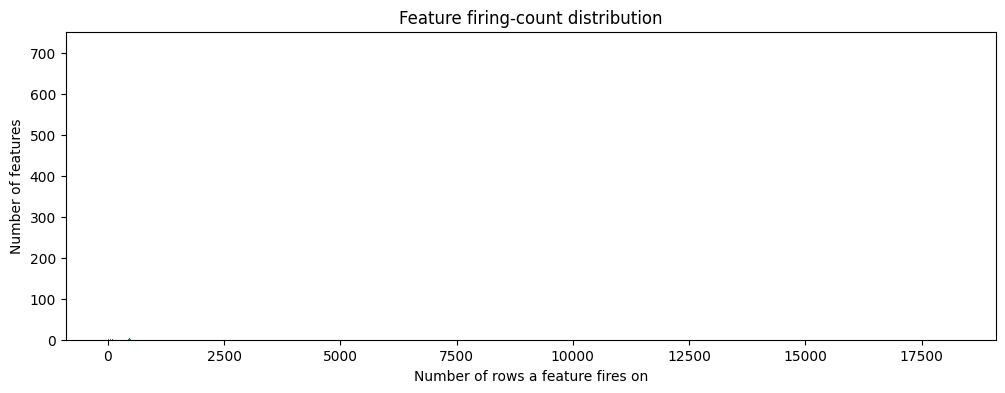

In [22]:
import matplotlib.pyplot as plt

feature_firing_count = (feature_matrix > 0).sum(dim=0)
counts = torch.bincount(feature_firing_count)

plt.figure(figsize=(12, 4))
plt.bar(range(len(counts)), counts.numpy())
plt.xlabel("Number of rows a feature fires on")
plt.ylabel("Number of features")
plt.title("Feature firing-count distribution")
plt.show()


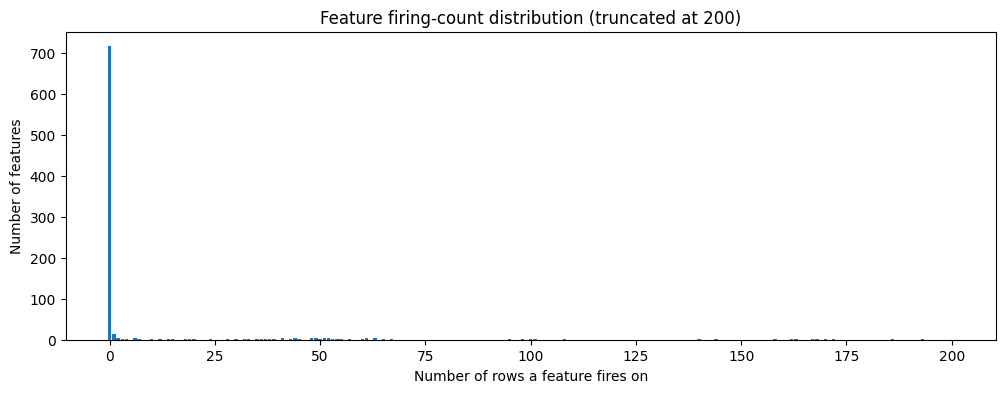

In [23]:
max_x = min(200, int(feature_firing_count.max().item()))

counts = torch.bincount(feature_firing_count, minlength=max_x + 1)

plt.figure(figsize=(12, 4))
plt.bar(range(max_x + 1), counts[: max_x + 1].numpy())
plt.xlabel("Number of rows a feature fires on")
plt.ylabel("Number of features")
plt.title(f"Feature firing-count distribution (truncated at {max_x})")
plt.show()


In [24]:
print("Features firing > 200 rows:", (feature_firing_count > 200).sum().item())
print("Features firing > 1000 rows:", (feature_firing_count > 1000).sum().item())


Features firing > 200 rows: 202
Features firing > 1000 rows: 25


In [25]:
feature_firing_count = (feature_matrix > 0).sum(dim=0).cpu()
feature_total_mass = feature_matrix.sum(dim=0).cpu()

live_features = (feature_firing_count > 0).nonzero(as_tuple=False).flatten()
nontrivial_live_features = (feature_firing_count > 10).nonzero(as_tuple=False).flatten()

print("Total features:", feature_matrix.shape[1])
print("Dead features:", int((feature_firing_count == 0).sum().item()))
print("Live features:", int(live_features.numel()))
print("Nontrivial live features (>10 firings):", int(nontrivial_live_features.numel()))
print()

print("Top 10 features by firing count:")
top_fire_vals, top_fire_idx = torch.topk(feature_firing_count, 10)
for feat_idx, count in zip(top_fire_idx.tolist(), top_fire_vals.tolist()):
    print(f"  feature {feat_idx:4d}: fires on {count} rows")

print()
print("Top 10 features by total activation mass:")
top_mass_vals, top_mass_idx = torch.topk(feature_total_mass, 10)
for feat_idx, mass in zip(top_mass_idx.tolist(), top_mass_vals.tolist()):
    print(f"  feature {feat_idx:4d}: total mass {mass:.4f}")


Total features: 1024
Dead features: 717
Live features: 307
Nontrivial live features (>10 firings): 278

Top 10 features by firing count:
  feature  824: fires on 18185 rows
  feature  572: fires on 16505 rows
  feature  690: fires on 16191 rows
  feature  928: fires on 15771 rows
  feature   54: fires on 15200 rows
  feature  872: fires on 15008 rows
  feature 1000: fires on 14912 rows
  feature  298: fires on 14884 rows
  feature  567: fires on 14829 rows
  feature  279: fires on 14629 rows

Top 10 features by total activation mass:
  feature  824: total mass 3232.7773
  feature  690: total mass 2936.6433
  feature  928: total mass 2741.8540
  feature  279: total mass 2636.1777
  feature   54: total mass 2520.1418
  feature  872: total mass 2503.7168
  feature  572: total mass 2493.5542
  feature  567: total mass 2474.4407
  feature  179: total mass 2296.7544
  feature  298: total mass 2258.8916


In [26]:
num_features = feature_matrix.shape[1]

mass_by_e1 = torch.zeros(num_features, E)
mass_by_t = torch.zeros(num_features, T)
mass_by_e2 = torch.zeros(num_features, E)
mass_by_addr = torch.zeros(num_features, E * T)

for i in tqdm(range(feature_matrix.shape[0])):
    feat_vals = feature_matrix[i]  # [d_sae]

    mass_by_e1[:, e1_labels[i]] += feat_vals
    mass_by_t[:, t_labels[i]] += feat_vals
    mass_by_e2[:, e2_labels[i]] += feat_vals
    mass_by_addr[:, addr_labels[i]] += feat_vals


100%|██████████| 47762/47762 [00:01<00:00, 32845.21it/s]


In [27]:
summary_rows = []

for feat_idx in live_features.tolist():
    total_mass = float(feature_total_mass[feat_idx].item())
    firing_count = int(feature_firing_count[feat_idx].item())
    firing_rate = firing_count / feature_matrix.shape[0]

    mean_when_fired = total_mass / firing_count if firing_count > 0 else 0.0
    max_activation = float(feature_matrix[:, feat_idx].max().item())

    e1_mass = mass_by_e1[feat_idx]
    t_mass = mass_by_t[feat_idx]
    e2_mass = mass_by_e2[feat_idx]
    addr_mass = mass_by_addr[feat_idx]

    top_e1 = int(e1_mass.argmax().item())
    top_t = int(t_mass.argmax().item())
    top_e2 = int(e2_mass.argmax().item())
    top_addr = int(addr_mass.argmax().item())

    top_addr_e1 = top_addr // T
    top_addr_t_rel = top_addr % T
    top_addr_t = top_addr_t_rel + E

    summary_rows.append(
        {
            "feature_idx": feat_idx,
            "firing_count": firing_count,
            "firing_rate": firing_rate,
            "total_mass": total_mass,
            "mean_when_fired": mean_when_fired,
            "max_activation": max_activation,
            "top_e1": top_e1,
            "top_e1_name": id_to_entity[top_e1],
            "top_e1_share": float(e1_mass[top_e1].item() / total_mass),
            "top_t": top_t,
            "top_t_name": id_to_entity[top_t + E],
            "top_t_share": float(t_mass[top_t].item() / total_mass),
            "top_e2": top_e2,
            "top_e2_name": id_to_entity[top_e2],
            "top_e2_share": float(e2_mass[top_e2].item() / total_mass),
            "top_addr_idx": top_addr,
            "top_addr_e1": top_addr_e1,
            "top_addr_t": top_addr_t,
            "top_addr_name": f"{id_to_entity[top_addr_e1]} | {id_to_entity[top_addr_t]}",
            "top_addr_share": float(addr_mass[top_addr].item() / total_mass),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.head()


,feature_idx,firing_count,firing_rate,total_mass,mean_when_fired,max_activation,top_e1,top_e1_name,top_e1_share,top_t,top_t_name,top_t_share,top_e2,top_e2_name,top_e2_share,top_addr_idx,top_addr_e1,top_addr_t,top_addr_name,top_addr_share
0,0,943,0.019744,121.926552,0.129296,0.202294,3,Jeffrey,0.020096,5,is interested in,0.121293,95,Patrick,0.771402,43,4,103,Jill | lives with,0.006518
1,12,487,0.010196,76.831291,0.157764,0.165308,45,Jesse,0.020771,1,works with,0.112347,81,Jose,1.000000,53,5,103,Erica | lives with,0.008218
2,14,108,0.002261,8.565723,0.079312,0.101802,54,Deborah,0.986957,4,has a grudge against,0.533150,17,Bridget,0.038900,544,54,104,Deborah | has a grudge against,0.533150
3,15,472,0.009882,65.577621,0.138936,0.169915,95,Patrick,0.992281,8,is jealous of,0.134122,79,John,0.025623,958,95,108,Patrick | is jealous of,0.132937
4,16,61,0.001277,5.797311,0.095038,0.127278,81,Jose,1.000000,2,interacts with,1.000000,51,Jason,0.047595,812,81,102,Jose | interacts with,1.000000


In [28]:
cols_to_show = [
    "feature_idx",
    "firing_count",
    "total_mass",
    "max_activation",
    "top_e1_name",
    "top_e1_share",
    "top_t_name",
    "top_t_share",
    "top_e2_name",
    "top_e2_share",
    "top_addr_name",
    "top_addr_share",
]

print("Top address-selective features")
display(summary_df.sort_values("top_addr_share", ascending=False)[cols_to_show].head(20))

print("Top E2-selective features")
display(summary_df.sort_values("top_e2_share", ascending=False)[cols_to_show].head(20))

print("Top E1-selective features")
display(summary_df.sort_values("top_e1_share", ascending=False)[cols_to_show].head(20))

print("Top T-selective features")
display(summary_df.sort_values("top_t_share", ascending=False)[cols_to_show].head(20))


Top address-selective features


,feature_idx,firing_count,total_mass,max_activation,top_e1_name,top_e1_share,top_t_name,top_t_share,top_e2_name,top_e2_share,top_addr_name,top_addr_share
4,16,61,5.797311,0.127278,Jose,1.0,interacts with,1.0,Jason,0.047595,Jose | interacts with,1.0
99,335,52,2.333710,0.052552,Mitchell,1.0,has a grudge against,1.0,Erica,0.062590,Mitchell | has a grudge against,1.0
94,316,48,3.258945,0.078183,Debra,1.0,wants,1.0,Reginald,0.058313,Debra | wants,1.0
268,888,45,3.504432,0.094536,Jason,1.0,works with,1.0,Melanie,0.069136,Jason | works with,1.0
65,216,44,1.894329,0.050978,Jeremy,1.0,plays with,1.0,Brenda,0.067874,Jeremy | plays with,1.0
116,372,48,2.199723,0.052511,George,1.0,wants,1.0,Angel,0.062072,George | wants,1.0
230,734,38,2.212241,0.073291,William,1.0,is interested in,1.0,Danielle,0.067158,William | is interested in,1.0
135,436,51,2.373755,0.054232,Mitchell,1.0,works with,1.0,Amy,0.082973,Mitchell | works with,1.0
5,18,43,2.892688,0.084278,Randall,1.0,goes to school with,1.0,Michael,0.049229,Randall | goes to school with,1.0
153,476,33,1.460037,0.054619,Danielle,1.0,interacts with,1.0,Daniel,0.085023,Danielle | interacts with,1.0


Top E2-selective features


,feature_idx,firing_count,total_mass,max_activation,top_e1_name,top_e1_share,top_t_name,top_t_share,top_e2_name,top_e2_share,top_addr_name,top_addr_share
240,772,455,82.165222,0.184653,Brenda,0.028164,interacts with,0.137072,Leslie,1.000001,Laura | interacts with,0.008875
285,931,487,75.517975,0.161146,Jill,0.024591,is jealous of,0.125124,Randall,1.000001,Andrea | wants,0.008157
100,336,482,63.800846,0.160621,Anthony,0.021363,works with,0.117035,Jessica,1.000000,Cassandra | wants,0.007497
168,536,442,64.888809,0.152871,Jill,0.025268,lives with,0.124103,Danielle,1.000000,Jessica | has a grudge against,0.009146
177,552,482,106.357452,0.226796,Bryan,0.019015,works with,0.116158,Frank,1.000000,Teresa | wants,0.008198
220,711,475,70.940636,0.155776,Michelle,0.025571,lives with,0.138799,Matthew,1.000000,Chelsea | lives with,0.008642
28,80,466,73.676186,0.165163,Teresa,0.023645,goes to school with,0.113406,Colin,1.000000,Sharon | goes to school with,0.008466
191,617,509,79.855881,0.165485,Bryan,0.021898,works with,0.123596,Joshua,1.000000,Jeremy | works with,0.007712
9,32,491,81.888260,0.180412,Diana,0.026546,has a grudge against,0.123679,Rachael,1.000000,Jose | has a grudge against,0.007831
11,34,491,89.666229,0.187711,Melanie,0.020756,is jealous of,0.120304,Sharon,1.000000,Nicholas | loves,0.006216


Top E1-selective features


,feature_idx,firing_count,total_mass,max_activation,top_e1_name,top_e1_share,top_t_name,top_t_share,top_e2_name,top_e2_share,top_addr_name,top_addr_share
214,694,285,19.501457,0.098130,Brandon,1.0,wants,0.188692,Christopher,0.032661,Brandon | wants,0.188692
101,337,477,32.148968,0.081947,Lisa,1.0,is interested in,0.117675,Gabrielle,0.029810,Lisa | is interested in,0.117675
4,16,61,5.797311,0.127278,Jose,1.0,interacts with,1.000000,Jason,0.047595,Jose | interacts with,1.000000
99,335,52,2.333710,0.052552,Mitchell,1.0,has a grudge against,1.000000,Erica,0.062590,Mitchell | has a grudge against,1.000000
304,1003,193,12.916947,0.085642,Debra,1.0,is interested in,0.274101,Susan,0.030611,Debra | is interested in,0.274101
94,316,48,3.258945,0.078183,Debra,1.0,wants,1.000000,Reginald,0.058313,Debra | wants,1.000000
207,674,257,27.186031,0.137052,Amanda,1.0,loves,0.269584,Keith,0.030392,Amanda | loves,0.269584
268,888,45,3.504432,0.094536,Jason,1.0,works with,1.000000,Melanie,0.069136,Jason | works with,1.000000
65,216,44,1.894329,0.050978,Jeremy,1.0,plays with,1.000000,Brenda,0.067874,Jeremy | plays with,1.000000
212,687,477,32.777744,0.084019,Veronica,1.0,is jealous of,0.118343,Jill,0.023865,Veronica | is jealous of,0.118343


Top T-selective features


,feature_idx,firing_count,total_mass,max_activation,top_e1_name,top_e1_share,top_t_name,top_t_share,top_e2_name,top_e2_share,top_addr_name,top_addr_share
4,16,61,5.797311,0.127278,Jose,1.000000,interacts with,1.0,Jason,0.047595,Jose | interacts with,1.000000
99,335,52,2.333710,0.052552,Mitchell,1.000000,has a grudge against,1.0,Erica,0.062590,Mitchell | has a grudge against,1.000000
94,316,48,3.258945,0.078183,Debra,1.000000,wants,1.0,Reginald,0.058313,Debra | wants,1.000000
268,888,45,3.504432,0.094536,Jason,1.000000,works with,1.0,Melanie,0.069136,Jason | works with,1.000000
65,216,44,1.894329,0.050978,Jeremy,1.000000,plays with,1.0,Brenda,0.067874,Jeremy | plays with,1.000000
116,372,48,2.199723,0.052511,George,1.000000,wants,1.0,Angel,0.062072,George | wants,1.000000
230,734,38,2.212241,0.073291,William,1.000000,is interested in,1.0,Danielle,0.067158,William | is interested in,1.000000
135,436,51,2.373755,0.054232,Mitchell,1.000000,works with,1.0,Amy,0.082973,Mitchell | works with,1.000000
238,762,49,5.039062,0.130130,Allison,0.984573,loves,1.0,William,0.062393,Allison | loves,0.984573
16,44,49,2.776272,0.072893,Brandon,0.973045,works with,1.0,Chelsea,0.067850,Brandon | works with,0.973045


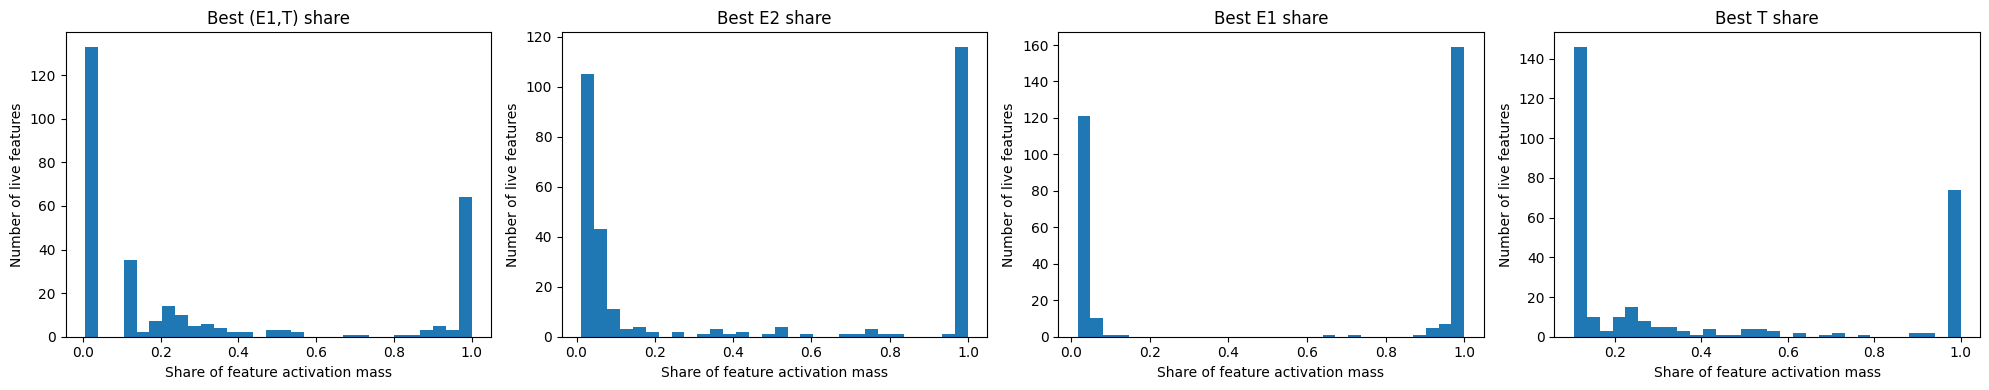

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

share_cols = [
    ("top_addr_share", "Best (E1,T) share"),
    ("top_e2_share", "Best E2 share"),
    ("top_e1_share", "Best E1 share"),
    ("top_t_share", "Best T share"),
]

for ax, (col, title) in zip(axes, share_cols):
    ax.hist(summary_df[col], bins=30)
    ax.set_title(title)
    ax.set_xlabel("Share of feature activation mass")
    ax.set_ylabel("Number of live features")

plt.tight_layout()
plt.show()


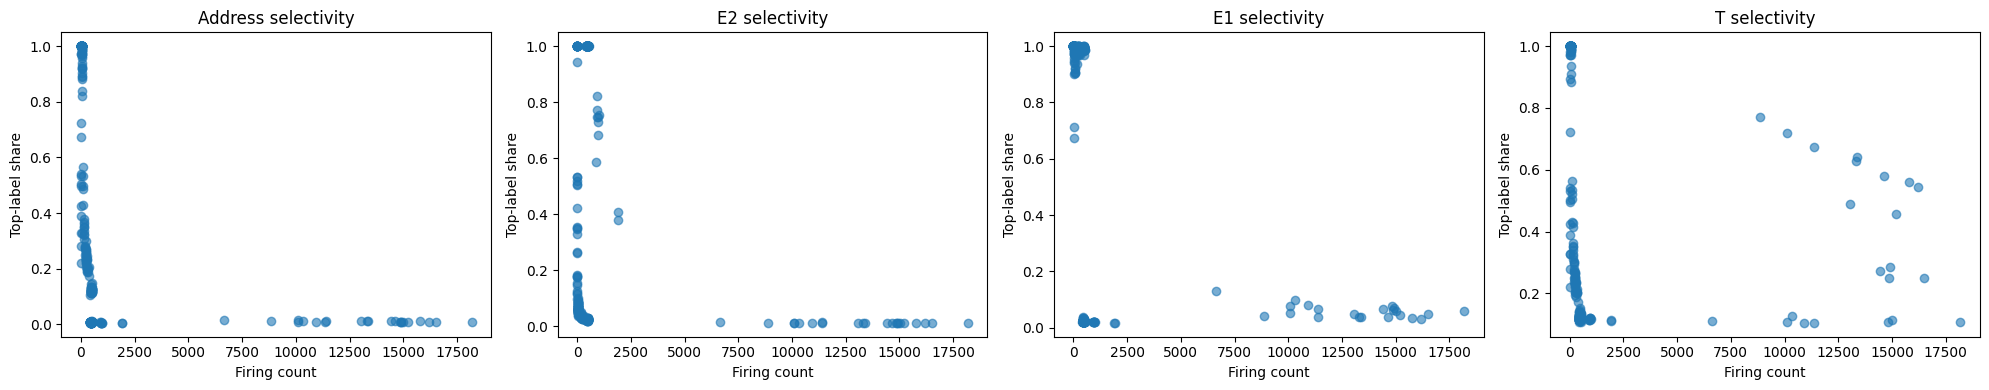

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)

scatter_cols = [
    ("top_addr_share", "Address selectivity"),
    ("top_e2_share", "E2 selectivity"),
    ("top_e1_share", "E1 selectivity"),
    ("top_t_share", "T selectivity"),
]

for ax, (col, title) in zip(axes, scatter_cols):
    ax.scatter(summary_df["firing_count"], summary_df[col], alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Firing count")
    ax.set_ylabel("Top-label share")

plt.tight_layout()
plt.show()


In [31]:
# Tune these if needed, but these are reasonable first cuts
MIN_FIRING_E2 = 100
MIN_FIRING_ADDR = 10
MIN_SHARE_E2 = 0.90
MIN_SHARE_ADDR = 0.90

strong_e2_df = summary_df[
    (summary_df["firing_count"] >= MIN_FIRING_E2) & (summary_df["top_e2_share"] >= MIN_SHARE_E2)
].copy()

strong_addr_df = summary_df[
    (summary_df["firing_count"] >= MIN_FIRING_ADDR)
    & (summary_df["top_addr_share"] >= MIN_SHARE_ADDR)
].copy()

print("Strong E2-selective features:", len(strong_e2_df))
print("Strong address-selective features:", len(strong_addr_df))
print()

e2_multiplicity = (
    strong_e2_df.groupby(["top_e2", "top_e2_name"])
    .agg(
        n_features=("feature_idx", "count"),
        feature_list=("feature_idx", lambda x: list(x)),
        mean_firing_count=("firing_count", "mean"),
        mean_share=("top_e2_share", "mean"),
    )
    .sort_values(["n_features", "mean_firing_count"], ascending=[False, False])
    .reset_index()
)

addr_multiplicity = (
    strong_addr_df.groupby(["top_addr_idx", "top_addr_name"])
    .agg(
        n_features=("feature_idx", "count"),
        feature_list=("feature_idx", lambda x: list(x)),
        mean_firing_count=("firing_count", "mean"),
        mean_share=("top_addr_share", "mean"),
    )
    .sort_values(["n_features", "mean_firing_count"], ascending=[False, False])
    .reset_index()
)

print("Top E2 multiplicity")
display(e2_multiplicity)

print("Top address multiplicity")
display(addr_multiplicity)


Strong E2-selective features: 101
Strong address-selective features: 48

Top E2 multiplicity


,top_e2,top_e2_name,n_features,feature_list,mean_firing_count,mean_share
0,57,Jessica,3,"[336, 527, 637]",482.000000,1.000000
1,51,Jason,3,"[226, 882, 951]",481.000000,1.000000
2,76,Robin,3,"[236, 459, 908]",470.333333,0.999849
3,20,Linda,3,"[130, 542, 550]",443.000000,1.000000
4,83,Rachael,2,"[32, 159]",491.000000,1.000000
...,...,...,...,...,...,...
84,61,Danielle,1,[536],442.000000,1.000000
85,92,Laura,1,[472],442.000000,1.000000
86,82,Brenda,1,[355],436.000000,1.000000
87,5,Erica,1,[878],432.000000,1.000000


Top address multiplicity


,top_addr_idx,top_addr_name,n_features,feature_list,mean_firing_count,mean_share
0,898,Brandon | is jealous of,1,[171],67.0,0.904477
1,837,Rachael | goes to school with,1,[647],65.0,0.918530
2,556,Chelsea | plays with,1,[795],63.0,0.992011
3,836,Rachael | plays with,1,[623],63.0,0.920541
4,812,Jose | interacts with,1,[16],61.0,1.000000
5,839,Rachael | wants,1,[884],61.0,0.982052
6,414,Brandon | has a grudge against,1,[528],60.0,0.922699
7,531,Sharon | works with,1,[974],57.0,0.957340
8,369,Maria | wants,1,[64],55.0,1.000000
9,484,Cynthia | has a grudge against,1,[376],54.0,1.000000


In [32]:
addr_feature_mass = torch.zeros(E * T, feature_matrix.shape[1])

for row_idx, addr_idx in enumerate(addr_labels.tolist()):
    addr_feature_mass[addr_idx] += feature_matrix[row_idx]

address_rows = []

for addr_idx in range(E * T):
    vec = addr_feature_mass[addr_idx]
    total_mass = float(vec.sum().item())

    e1 = addr_idx // T
    t_rel = addr_idx % T
    t_tok = t_rel + E
    addr_name = f"{id_to_entity[e1]} | {id_to_entity[t_tok]}"

    if total_mass == 0:
        address_rows.append(
            {
                "addr_idx": addr_idx,
                "addr_name": addr_name,
                "total_mass": 0.0,
                "n_live_features": 0,
                "top_feature": None,
                "top_feature_share": 0.0,
                "features_for_50pct": None,
                "features_for_80pct": None,
            }
        )
        continue

    sorted_vals, sorted_idx = torch.sort(vec, descending=True)
    shares = sorted_vals / total_mass
    cumsum = torch.cumsum(shares, dim=0)

    n_live = int((vec > 0).sum().item())
    top_feature = int(sorted_idx[0].item())
    top_feature_share = float(shares[0].item())
    features_for_50pct = int((cumsum < 0.5).sum().item()) + 1
    features_for_80pct = int((cumsum < 0.8).sum().item()) + 1

    address_rows.append(
        {
            "addr_idx": addr_idx,
            "addr_name": addr_name,
            "total_mass": total_mass,
            "n_live_features": n_live,
            "top_feature": top_feature,
            "top_feature_share": top_feature_share,
            "features_for_50pct": features_for_50pct,
            "features_for_80pct": features_for_80pct,
        }
    )

address_df = pd.DataFrame(address_rows)
address_df.head(50)


,addr_idx,addr_name,total_mass,n_live_features,top_feature,top_feature_share,features_for_50pct,features_for_80pct
0,0,Danielle | loves,60.342197,53,824,0.232085,3,7
1,1,Danielle | works with,42.079559,42,824,0.279012,2,6
2,2,Danielle | interacts with,53.015919,47,824,0.248827,3,5
3,3,Danielle | lives with,68.848793,51,824,0.232332,3,7
4,4,Danielle | has a grudge against,53.793121,49,179,0.283500,2,6
5,5,Danielle | is interested in,73.053642,60,824,0.259628,3,6
6,6,Danielle | plays with,78.845184,57,824,0.228544,3,7
7,7,Danielle | goes to school with,65.903748,52,824,0.234532,3,7
8,8,Danielle | is jealous of,55.432899,51,824,0.235024,3,7
9,9,Danielle | wants,81.835670,62,248,0.224631,3,7


In [33]:
print("Address coverage summary")
print(
    address_df[
        ["n_live_features", "top_feature_share", "features_for_50pct", "features_for_80pct"]
    ].describe()
)


Address coverage summary
       n_live_features  top_feature_share  features_for_50pct  \
count      1000.000000        1000.000000         1000.000000   
mean         54.182000           0.240825            3.200000   
std           6.431815           0.052068            0.666667   
min          33.000000           0.116031            2.000000   
25%          50.000000           0.205301            3.000000   
50%          54.000000           0.234515            3.000000   
75%          59.000000           0.268936            4.000000   
max          72.000000           0.468979            5.000000   

       features_for_80pct  
count         1000.000000  
mean             6.576000  
std              1.290694  
min              4.000000  
25%              6.000000  
50%              7.000000  
75%              7.000000  
max             14.000000  


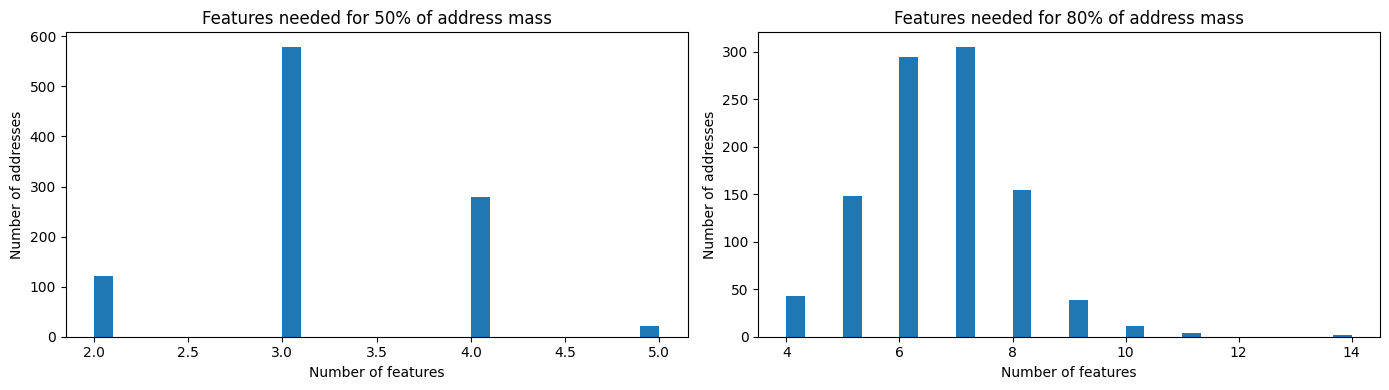

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(address_df["features_for_50pct"].dropna(), bins=30)
axes[0].set_title("Features needed for 50% of address mass")
axes[0].set_xlabel("Number of features")
axes[0].set_ylabel("Number of addresses")

axes[1].hist(address_df["features_for_80pct"].dropna(), bins=30)
axes[1].set_title("Features needed for 80% of address mass")
axes[1].set_xlabel("Number of features")
axes[1].set_ylabel("Number of addresses")

plt.tight_layout()
plt.show()


In [35]:
print("Most compact addresses")
display(
    address_df.sort_values(
        ["features_for_80pct", "features_for_50pct", "top_feature_share"],
        ascending=[True, True, False],
    ).head(20)
)

print("Most diffuse addresses")
display(
    address_df.sort_values(
        ["features_for_80pct", "features_for_50pct", "top_feature_share"],
        ascending=[False, False, True],
    ).head(20)
)


Most compact addresses


,addr_idx,addr_name,total_mass,n_live_features,top_feature,top_feature_share,features_for_50pct,features_for_80pct
550,550,Chelsea | loves,57.317947,54,874,0.382905,2,4
123,123,Anthony | lives with,44.600479,48,690,0.373054,2,4
740,740,Diana | loves,59.430702,56,567,0.357327,2,4
738,738,Leonard | is jealous of,57.285606,49,279,0.353918,2,4
747,747,Diana | goes to school with,54.892960,45,567,0.348838,2,4
534,534,Sharon | has a grudge against,43.200546,47,179,0.342129,2,4
89,89,Robert | wants,59.545174,51,248,0.340972,2,4
743,743,Diana | lives with,61.277206,52,567,0.338855,2,4
453,453,Jesse | lives with,83.894356,64,690,0.337943,2,4
433,433,Keith | lives with,71.237617,62,690,0.337106,2,4


Most diffuse addresses


,addr_idx,addr_name,total_mass,n_live_features,top_feature,top_feature_share,features_for_50pct,features_for_80pct
847,847,Reginald | goes to school with,32.099304,52,94,0.231253,3,14
843,843,Reginald | lives with,27.941431,52,572,0.282738,3,14
224,224,Matthew | has a grudge against,29.214163,44,179,0.239556,3,11
846,846,Reginald | plays with,45.258446,57,928,0.249892,3,11
842,842,Reginald | interacts with,49.970715,58,572,0.282635,3,11
493,493,Michael | lives with,52.352905,62,872,0.275560,2,11
577,577,Jessica | goes to school with,48.135059,50,94,0.139311,5,10
294,294,Cassandra | has a grudge against,52.956932,63,179,0.162126,4,10
293,293,Cassandra | lives with,60.127682,58,690,0.176246,4,10
780,780,Joseph | loves,53.555389,55,532,0.206831,4,10


In [47]:
# Generic precision / coverage analysis for resid_post SAE features
allowed_features = (feature_firing_count > 10) & (feature_firing_count <= 14000)

print("Allowed features:", int(allowed_features.sum().item()))
print("Excluded broad features:", int((feature_firing_count > 5000).sum().item()))


def build_label_names():
    e1_names = [id_to_entity[i] for i in range(E)]
    t_names = [id_to_entity[i + E] for i in range(T)]
    e2_names = [id_to_entity[i] for i in range(E)]

    addr_names = []
    for e1 in range(E):
        for t_rel in range(T):
            addr_names.append(f"{id_to_entity[e1]} | {id_to_entity[t_rel + E]}")
    return e1_names, t_names, e2_names, addr_names


def analyze_label_space_filtered(
    feature_matrix, labels, label_names, feature_firing_count, allowed_features, topk_offtargets=5
):
    num_labels = len(label_names)
    num_features = feature_matrix.shape[1]

    label_feature_count = torch.zeros(num_labels, num_features, dtype=torch.long)
    label_feature_mass = torch.zeros(num_labels, num_features, dtype=torch.float32)
    label_row_count = torch.zeros(num_labels, dtype=torch.long)

    for row_idx in range(feature_matrix.shape[0]):
        lab = int(labels[row_idx].item())
        vals = feature_matrix[row_idx]
        active = vals > 0

        label_feature_count[lab] += active.long()
        label_feature_mass[lab] += vals
        label_row_count[lab] += 1

    rows = []

    for lab in range(num_labels):
        counts = label_feature_count[lab].clone()

        # Mask out dead / overly broad features
        counts[~allowed_features] = -1

        top_feat = int(counts.argmax().item())
        if counts[top_feat].item() < 0:
            raise ValueError(f"No allowed feature available for label {label_names[lab]}")

        fires_on_label = int(label_feature_count[lab, top_feat].item())
        total_fires = int(feature_firing_count[top_feat].item())
        coverage = fires_on_label / max(int(label_row_count[lab].item()), 1)
        precision = fires_on_label / max(total_fires, 1)

        fires_by_label = label_feature_count[:, top_feat].clone()
        fires_by_label[lab] = 0
        off_vals, off_idx = torch.topk(fires_by_label, topk_offtargets)

        rows.append(
            {
                "label_idx": lab,
                "label_name": label_names[lab],
                "top_feature": top_feat,
                "rows_for_label": int(label_row_count[lab].item()),
                "fires_on_label": fires_on_label,
                "total_fires_of_feature": total_fires,
                "coverage_on_label": coverage,
                "precision_for_label": precision,
                "top_offtarget_labels": [label_names[int(i)] for i in off_idx.tolist()],
                "top_offtarget_counts": off_vals.tolist(),
            }
        )

    df = pd.DataFrame(rows)
    return df, label_feature_count, label_feature_mass, label_row_count


e1_names, t_names, e2_names, addr_names = build_label_names()

e1_cov_df_f, _, _, _ = analyze_label_space_filtered(
    feature_matrix, e1_labels, e1_names, feature_firing_count, allowed_features
)

t_cov_df_f, _, _, _ = analyze_label_space_filtered(
    feature_matrix, t_labels, t_names, feature_firing_count, allowed_features
)

e2_cov_df_f, _, _, _ = analyze_label_space_filtered(
    feature_matrix, e2_labels, e2_names, feature_firing_count, allowed_features
)

addr_cov_df_f, _, _, _ = analyze_label_space_filtered(
    feature_matrix, addr_labels, addr_names, feature_firing_count, allowed_features
)


Allowed features: 267
Excluded broad features: 22


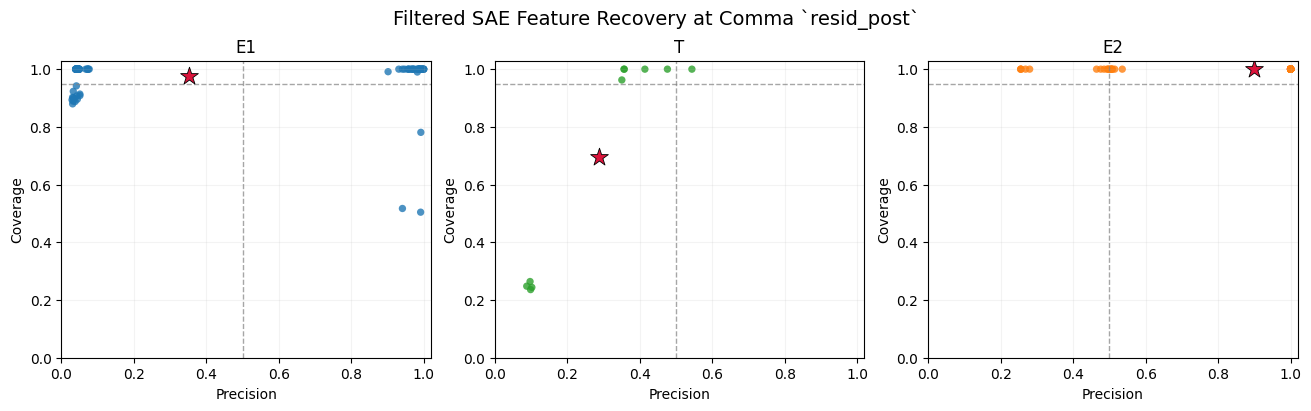

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Expect these to already exist:
# e1_cov_df, t_cov_df, e2_cov_df, addr_cov_df

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

panels = [
    (e1_cov_df_f, "E1", "#1f77b4"),
    (t_cov_df_f, "T", "#2ca02c"),
    (e2_cov_df_f, "E2", "#ff7f0e"),
]

for ax, (df, title, color) in zip(axes, panels):
    x = df["precision_for_label"].to_numpy()
    y = df["coverage_on_label"].to_numpy()

    ax.scatter(x, y, s=28, alpha=0.8, color=color, edgecolors="none")

    x_mean = float(np.mean(x))
    y_mean = float(np.mean(y))
    ax.scatter(
        [x_mean],
        [y_mean],
        marker="*",
        s=180,
        color="crimson",
        edgecolors="black",
        linewidths=0.6,
        zorder=5,
    )

    ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(0.95, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.03)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Precision")
    ax.set_ylabel("Coverage")
    ax.grid(alpha=0.15)

fig.suptitle("Filtered SAE Feature Recovery at Comma `resid_post`", fontsize=14)
plt.show()


In [49]:
import numpy as np
import matplotlib.pyplot as plt


def analyze_label_space_best_f1(
    feature_matrix, labels, label_names, feature_firing_count, min_feature_fires=1
):
    num_labels = len(label_names)
    num_features = feature_matrix.shape[1]

    label_feature_count = torch.zeros(num_labels, num_features, dtype=torch.long)
    label_row_count = torch.zeros(num_labels, dtype=torch.long)

    for row_idx in range(feature_matrix.shape[0]):
        lab = int(labels[row_idx].item())
        vals = feature_matrix[row_idx]
        active = vals > 0

        label_feature_count[lab] += active.long()
        label_row_count[lab] += 1

    rows = []

    valid_features = feature_firing_count >= min_feature_fires

    for lab in range(num_labels):
        tp = label_feature_count[lab].float()  # fires on this label
        total_fires = feature_firing_count.float()  # fires anywhere
        total_label_rows = float(label_row_count[lab].item())

        precision = tp / torch.clamp(total_fires, min=1.0)
        recall = tp / max(total_label_rows, 1.0)
        f1 = 2 * precision * recall / torch.clamp(precision + recall, min=1e-8)

        # mask out invalid features
        f1 = f1.clone()
        f1[~valid_features] = -1

        best_feat = int(f1.argmax().item())
        best_f1 = float(f1[best_feat].item())
        best_precision = float(precision[best_feat].item())
        best_recall = float(recall[best_feat].item())

        fires_by_label = label_feature_count[:, best_feat].clone()
        fires_by_label[lab] = 0
        off_vals, off_idx = torch.topk(fires_by_label, 5)

        rows.append(
            {
                "label_idx": lab,
                "label_name": label_names[lab],
                "best_feature": best_feat,
                "f1": best_f1,
                "precision": best_precision,
                "recall": best_recall,
                "rows_for_label": int(label_row_count[lab].item()),
                "fires_on_label": int(label_feature_count[lab, best_feat].item()),
                "total_fires_of_feature": int(feature_firing_count[best_feat].item()),
                "top_offtarget_labels": [label_names[int(i)] for i in off_idx.tolist()],
                "top_offtarget_counts": off_vals.tolist(),
            }
        )

    df = pd.DataFrame(rows)
    return df, label_feature_count, label_row_count


e1_f1_df, e1_feature_count_f1, e1_row_count_f1 = analyze_label_space_best_f1(
    feature_matrix, e1_labels, e1_names, feature_firing_count, min_feature_fires=1
)

t_f1_df, t_feature_count_f1, t_row_count_f1 = analyze_label_space_best_f1(
    feature_matrix, t_labels, t_names, feature_firing_count, min_feature_fires=1
)

e2_f1_df, e2_feature_count_f1, e2_row_count_f1 = analyze_label_space_best_f1(
    feature_matrix, e2_labels, e2_names, feature_firing_count, min_feature_fires=1
)

print("E1 mean F1:", e1_f1_df["f1"].mean())
print("T mean F1:", t_f1_df["f1"].mean())
print("E2 mean F1:", e2_f1_df["f1"].mean())


E1 mean F1: 0.5820145699754358
T mean F1: 0.5385070502758026
E2 mean F1: 0.9580173218250274


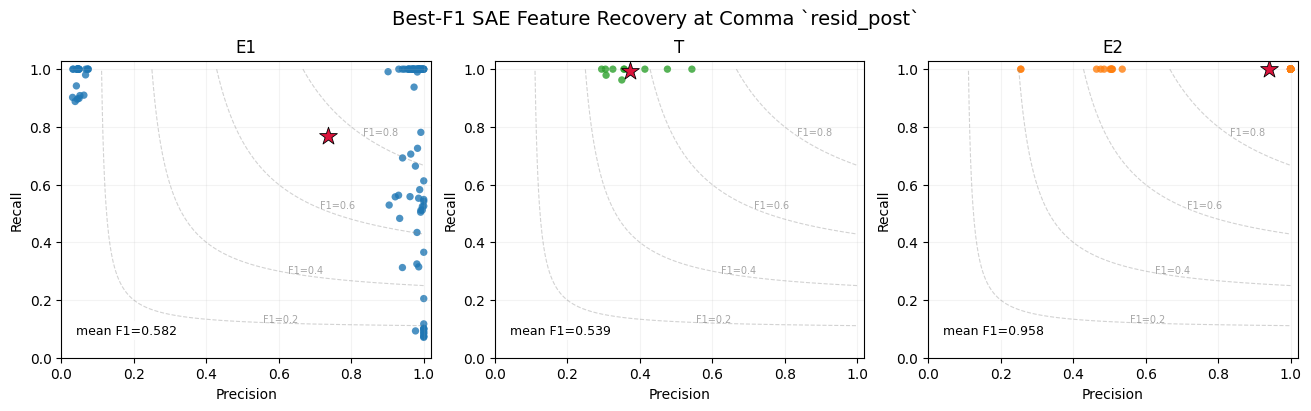

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

panels = [
    (e1_f1_df, "E1", "#1f77b4"),
    (t_f1_df, "T", "#2ca02c"),
    (e2_f1_df, "E2", "#ff7f0e"),
]

f1_levels = [0.2, 0.4, 0.6, 0.8]

for ax, (df, title, color) in zip(axes, panels):
    x = df["precision"].to_numpy()
    y = df["recall"].to_numpy()

    # iso-F1 curves
    p_grid = np.linspace(0.01, 1.0, 500)
    for f1_level in f1_levels:
        denom = 2 * p_grid - f1_level
        mask = denom > 0
        r = np.full_like(p_grid, np.nan)
        r[mask] = (f1_level * p_grid[mask]) / denom[mask]
        r[(r < 0) | (r > 1)] = np.nan
        ax.plot(p_grid, r, color="gray", linestyle="--", linewidth=0.8, alpha=0.35)
        valid_idx = np.where(~np.isnan(r))[0]
        if len(valid_idx) > 0:
            idx = valid_idx[len(valid_idx) // 2]
            ax.text(p_grid[idx], r[idx], f"F1={f1_level}", color="gray", fontsize=7, alpha=0.7)

    ax.scatter(x, y, s=28, alpha=0.8, color=color, edgecolors="none")

    x_mean = float(np.mean(x))
    y_mean = float(np.mean(y))
    ax.scatter(
        [x_mean],
        [y_mean],
        marker="*",
        s=180,
        color="crimson",
        edgecolors="black",
        linewidths=0.6,
        zorder=5,
    )

    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.03)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Precision")
    ax.set_ylabel("Recall")
    ax.grid(alpha=0.15)

    ax.text(
        0.04,
        0.08,
        f"mean F1={df['f1'].mean():.3f}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none"),
    )

fig.suptitle("Best-F1 SAE Feature Recovery at Comma `resid_post`", fontsize=14)
plt.show()


In [56]:
def analyze_label_space_best_f1(
    feature_matrix,
    labels,
    label_names,
    feature_firing_count,
    min_feature_fires=1,
    max_feature_fires=None,
):
    num_labels = len(label_names)
    num_features = feature_matrix.shape[1]

    label_feature_count = torch.zeros(num_labels, num_features, dtype=torch.long)
    label_row_count = torch.zeros(num_labels, dtype=torch.long)

    for row_idx in range(feature_matrix.shape[0]):
        lab = int(labels[row_idx].item())
        vals = feature_matrix[row_idx]
        active = vals > 0

        label_feature_count[lab] += active.long()
        label_row_count[lab] += 1

    rows = []

    valid_features = feature_firing_count >= min_feature_fires
    if max_feature_fires is not None:
        valid_features = valid_features & (feature_firing_count <= max_feature_fires)

    for lab in range(num_labels):
        tp = label_feature_count[lab].float()
        total_fires = feature_firing_count.float()
        total_label_rows = float(label_row_count[lab].item())

        precision = tp / torch.clamp(total_fires, min=1.0)
        recall = tp / max(total_label_rows, 1.0)
        f1 = 2 * precision * recall / torch.clamp(precision + recall, min=1e-8)

        f1 = f1.clone()
        f1[~valid_features] = -1

        best_feat = int(f1.argmax().item())
        best_f1 = float(f1[best_feat].item())
        best_precision = float(precision[best_feat].item())
        best_recall = float(recall[best_feat].item())

        rows.append(
            {
                "label_idx": lab,
                "label_name": label_names[lab],
                "best_feature": best_feat,
                "f1": best_f1,
                "precision": best_precision,
                "recall": best_recall,
                "rows_for_label": int(label_row_count[lab].item()),
                "fires_on_label": int(label_feature_count[lab, best_feat].item()),
                "total_fires_of_feature": int(feature_firing_count[best_feat].item()),
            }
        )

    return pd.DataFrame(rows)

addr_f1_df = analyze_label_space_best_f1(
    feature_matrix,
    addr_labels,
    addr_names,
    feature_firing_count,
)


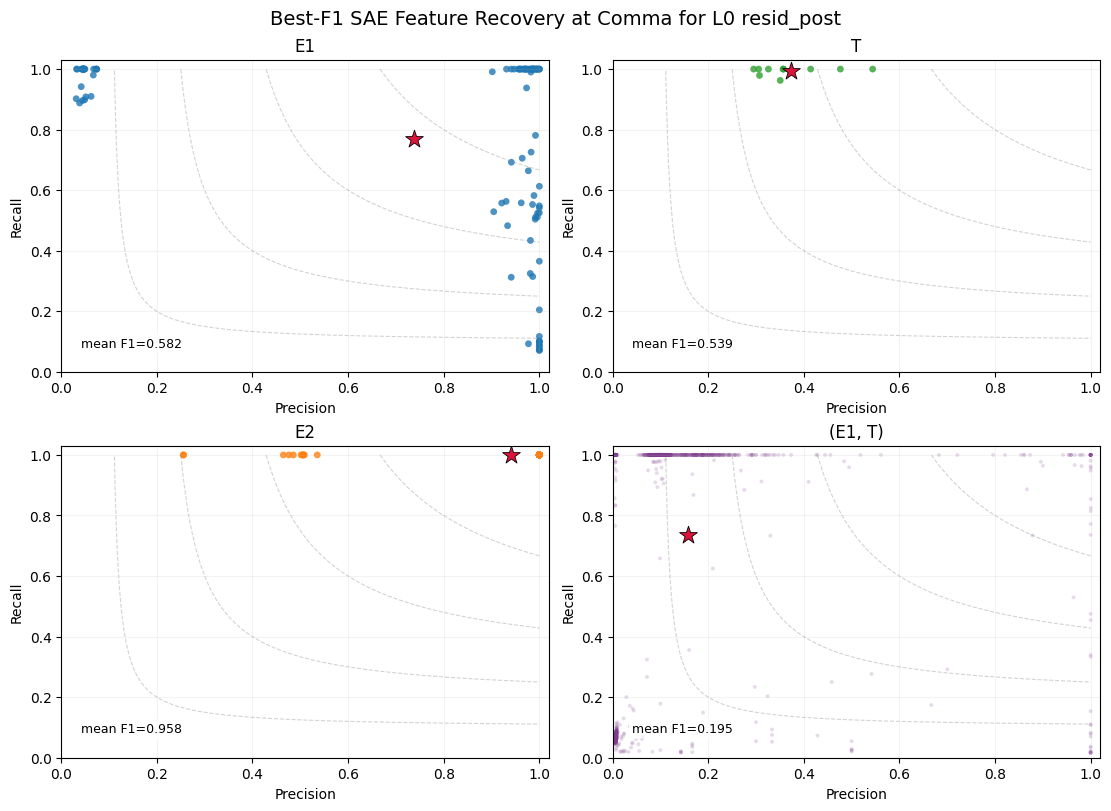

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

panels = [
    (e1_f1_df, "E1", "#1f77b4", 24, 0.80),
    (t_f1_df, "T", "#2ca02c", 24, 0.80),
    (e2_f1_df, "E2", "#ff7f0e", 24, 0.80),
    (addr_f1_df, "(E1, T)", "#7f3c8d", 8, 0.18),
]

f1_levels = [0.2, 0.4, 0.6, 0.8]

for ax, (df, title, color, size, alpha) in zip(axes.flatten(), panels):
    x = df["precision"].to_numpy()
    y = df["recall"].to_numpy()

    # iso-F1 curves
    p_grid = np.linspace(0.01, 1.0, 500)
    for f1_level in f1_levels:
        denom = 2 * p_grid - f1_level
        mask = denom > 0
        r = np.full_like(p_grid, np.nan)
        r[mask] = (f1_level * p_grid[mask]) / denom[mask]
        r[(r < 0) | (r > 1)] = np.nan
        ax.plot(p_grid, r, color="gray", linestyle="--", linewidth=0.8, alpha=0.35)

    ax.scatter(
        x,
        y,
        s=size,
        alpha=alpha,
        color=color,
        edgecolors="none",
    )

    x_mean = float(np.mean(x))
    y_mean = float(np.mean(y))
    f1_mean = float(df["f1"].mean())

    ax.scatter(
        [x_mean],
        [y_mean],
        marker="*",
        s=180,
        color="crimson",
        edgecolors="black",
        linewidths=0.6,
        zorder=5,
    )

    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.03)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Precision")
    ax.set_ylabel("Recall")
    ax.grid(alpha=0.15)

    ax.text(
        0.04,
        0.08,
        f"mean F1={f1_mean:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none"),
    )

fig.suptitle("Best-F1 SAE Feature Recovery at Comma for L0 resid_post", fontsize=14)
plt.savefig("s1e5_residpost_sae_feature_recovery_f1.png", dpi=300)
plt.show()


# Realization that we have features that fire ... everytime.. so coverage is misleading.
# Further realization that for (E1, T) we have features from E1 solely that would cover it - so need to exclude them too

In [43]:
too_narrow = feature_firing_count < 10

print("Features firing < 10 rows:", int(too_narrow.sum().item()))
print("Feature indices:", too_narrow.nonzero(as_tuple=False).flatten().tolist())


Features firing < 10 rows: 745
Feature indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 17, 19, 21, 22, 23, 24, 25, 27, 29, 30, 31, 35, 36, 37, 39, 41, 42, 45, 46, 48, 49, 50, 52, 55, 56, 57, 58, 59, 60, 61, 65, 66, 67, 68, 69, 70, 71, 72, 75, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 92, 93, 97, 98, 99, 100, 102, 103, 104, 105, 106, 108, 109, 110, 111, 112, 114, 115, 116, 117, 118, 120, 122, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 150, 152, 154, 155, 156, 157, 158, 160, 161, 162, 163, 164, 166, 167, 169, 170, 172, 177, 180, 181, 184, 185, 187, 188, 189, 190, 191, 192, 194, 195, 196, 197, 199, 201, 202, 203, 204, 205, 206, 207, 208, 210, 211, 213, 214, 215, 217, 218, 219, 220, 221, 222, 224, 225, 228, 229, 230, 231, 232, 233, 234, 235, 237, 238, 239, 240, 241, 242, 243, 244, 245, 247, 249, 250, 251, 252, 253, 254, 255, 257, 258, 259, 261, 262, 263, 264, 266, 268, 269, 270, 271, 272, 273, 274, 275, 276, 281

In [39]:
too_broad = feature_firing_count > 5000

print("Features firing > 5000 rows:", int(too_broad.sum().item()))
print("Feature indices:", too_broad.nonzero(as_tuple=False).flatten().tolist())


Features firing > 5000 rows: 22
Feature indices: [54, 94, 123, 179, 248, 279, 298, 466, 491, 532, 567, 572, 604, 690, 776, 824, 854, 872, 874, 891, 928, 1000]


In [40]:
broad_idx = too_broad.nonzero(as_tuple=False).flatten()

for feat_idx in broad_idx.tolist():
    print(f"feature {feat_idx}: fires on {int(feature_firing_count[feat_idx].item())} rows")


feature 54: fires on 15200 rows
feature 94: fires on 10104 rows
feature 123: fires on 14419 rows
feature 179: fires on 13374 rows
feature 248: fires on 8866 rows
feature 279: fires on 14629 rows
feature 298: fires on 14884 rows
feature 466: fires on 11378 rows
feature 491: fires on 13303 rows
feature 532: fires on 10332 rows
feature 567: fires on 14829 rows
feature 572: fires on 16505 rows
feature 604: fires on 10923 rows
feature 690: fires on 16191 rows
feature 776: fires on 6640 rows
feature 824: fires on 18185 rows
feature 854: fires on 10094 rows
feature 872: fires on 15008 rows
feature 874: fires on 11386 rows
feature 891: fires on 13049 rows
feature 928: fires on 15771 rows
feature 1000: fires on 14912 rows
